# CS6140 Machine Learning
## Problem Set 2: Probability Distributions & Parameter Estimation

This problem set asks you to:

1. Practice **visual diagnostics** (histograms, Q-Q plots) to understand distributions
2. **Compute empirical statistics** and compare to theoretical values
3. Use **method of moments** to estimate distribution parameters
4. Implement **grid search** to find optimal parameters for mixture distributions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import stats
from typing import Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load the dataset
data = np.loadtxt('mixture_data.csv', delimiter=',', skiprows=1)[:, 0]
print(f"Loaded {len(data)} samples")
print(f"Data range: [{data.min():.4f}, {data.max():.4f}]")
print(f"Mean: {data.mean():.4f}, Std: {data.std():.4f}")

Loaded 3000 samples
Data range: [0.3888, 407.5643]
Mean: 29.1675, Std: 57.8523


## Problem 1: Histogram and Kernel Density Estimation (4 pts)

Create a visualization showing:
1. A histogram of the raw data (use 50 bins)
2. A KDE (kernel density estimation) overlay to smooth the distribution

**Questions to consider**:
- Does the distribution look unimodal or multimodal?
- Where are the peaks?

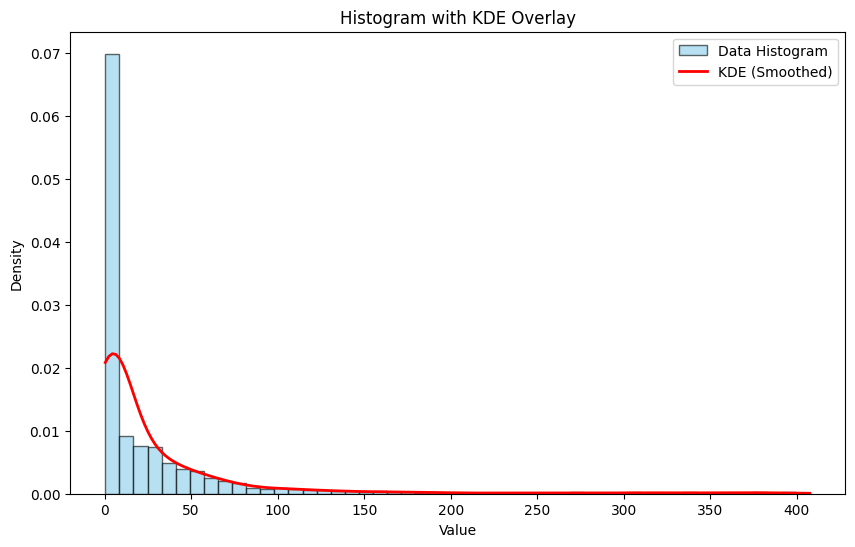

✓ Problem 1: Create histogram and KDE plot above


'\nAnswer 1:\nAt first glance, it looks unimodal because of that one massive spike on the left. But the tail on the right is \nreally long and thick, which strongly suggests there’s a second, flatter distribution hiding in there, \nso it iss likely multimodal (a mixture of two distributions).\n\nAnswer 2:\n'

In [ ]:
def plot_histogram_kde(data: np.ndarray, bins: int = 50) -> None:
    """
    Plot histogram with KDE overlay.
    
    Args:
        data: Array of values
        bins: Number of histogram bins
    
    TODO: Create a figure with:
    1. Histogram of data (use density=True so it's normalized)
    2. KDE curve overlaid using scipy.stats.gaussian_kde
    
    You can create KDE like this:
        kde = stats.gaussian_kde(data)
        x_vals = np.linspace(data.min(), data.max(), 200)
        plt.plot(x_vals, kde(x_vals), ...)
    """
    # Create the figure
    plt.figure(figsize=(10, 6))
    
    # 1. Plot histogram
    # Using density=True to normalize and compare it with KDE
    plt.hist(data, bins=bins, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Data Histogram')
    
    # 2. KDE curve
    # Calculating KDE using scipy
    kde = stats.gaussian_kde(data)
    
    # Create x values for plotting the curve
    x_min, x_max = data.min(), data.max()
    x_vals = np.linspace(x_min, x_max, 200)
    
    # Plot the KDE curve
    plt.plot(x_vals, kde(x_vals), 'r-', linewidth=2, label='KDE (Smoothed)')
    plt.legend()

plot_histogram_kde(data)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram with KDE Overlay')
plt.legend()
plt.show()

print("✓ Problem 1: Create histogram and KDE plot above")

"""
Answer 1:
At first glance, it looks unimodal because of that one massive spike on the left. But the tail on the right is 
really long and thick, which strongly suggests there’s a second, flatter distribution hiding in there, 
so it iss likely multimodal.

Answer 2:
The main peak is super sharp and is at right around 3 or 4. 
"""

## Problem 2: Q-Q Plots (6 pts)

Q-Q plots compare empirical quantiles from your data against theoretical quantiles from a distribution.

Create two Q-Q plots:
1. Q-Q plot against a log-normal distribution (with your best guess at parameters)
2. Q-Q plot against a Gaussian (normal) distribution (with your best guess at parameters)

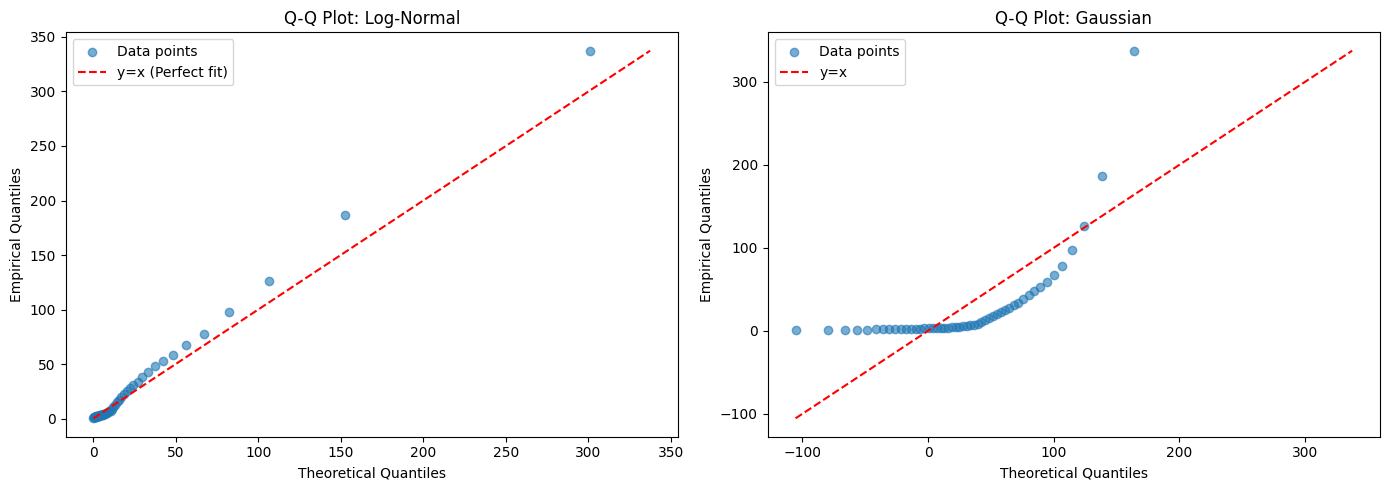

✓ Problem 2: Q-Q plots created above


In [9]:
def qq_plot_lognormal(data: np.ndarray, mu: float, sigma: float, ax=None) -> None:
    """
    Create a Q-Q plot comparing data to log-normal distribution.
    
    Args:
        data: Observed data
        mu: Mean of log-normal distribution
        sigma: Std dev of log-normal distribution
        ax: Matplotlib axis (optional)
    
    TODO: 
    1. Compute empirical quantiles from data using np.quantile
       - Use quantile values: np.linspace(0.01, 0.99, 50)
    2. Compute theoretical quantiles using scipy.stats.lognorm
    3. Plot empirical vs theoretical (theoretical on x-axis)
    4. Add a 45-degree reference line
    
    Hint: scipy.stats.lognorm.ppf(q, s, scale=exp(mu)) gives quantiles
    """
    if ax is None:
        ax = plt.gca()
    
    # 1. Computing empirical quantiles
    qs = np.linspace(0.01, 0.99, 50)
    empirical_quantiles = np.quantile(data, qs)
    
    # 2. Computing theoretical quantiles
    # For lognorm, s=sigma, scale=exp(mu)
    theoretical_quantiles = stats.lognorm.ppf(qs, s=sigma, scale=np.exp(mu))
    
    # 3. Plotting empirical vs theoretical
    ax.scatter(theoretical_quantiles, empirical_quantiles, alpha=0.6, label='Data points')
    
    # 4. Adding 45-degree reference line
    min_val = min(theoretical_quantiles.min(), empirical_quantiles.min())
    max_val = max(theoretical_quantiles.max(), empirical_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x (Perfect fit)')
    
    ax.legend()


def qq_plot_gaussian(data: np.ndarray, ax=None) -> None:
    """
    Create a Q-Q plot comparing data to Gaussian distribution.
    
    Args:
        data: Observed data
        ax: Matplotlib axis (optional)
    
    TODO: Similar to lognormal Q-Q plot, but use scipy.stats.norm
    """
    if ax is None:
        ax = plt.gca()
    
    # Estimating parameters from data for the Gaussian guess
    mu_est = np.mean(data)
    sigma_est = np.std(data)
    
    # 1. Computing empirical quantiles
    qs = np.linspace(0.01, 0.99, 50)
    empirical_quantiles = np.quantile(data, qs)
    
    # 2. Computing theoretical quantiles for Normal distribution
    theoretical_quantiles = stats.norm.ppf(qs, loc=mu_est, scale=sigma_est)
    
    # 3. Plotting
    ax.scatter(theoretical_quantiles, empirical_quantiles, alpha=0.6, label='Data points')
    
    # 4. Reference line
    min_val = min(theoretical_quantiles.min(), empirical_quantiles.min())
    max_val = max(theoretical_quantiles.max(), empirical_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')
    
    ax.legend()


# Create two Q-Q plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use rough estimates for now (you can refine these as you go)
qq_plot_lognormal(data, mu=2.17, sigma=1.52, ax=axes[0])
axes[0].set_title('Q-Q Plot: Log-Normal')
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Empirical Quantiles')

qq_plot_gaussian(data, ax=axes[1])
axes[1].set_title('Q-Q Plot: Gaussian')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Empirical Quantiles')

plt.tight_layout()
plt.show()

print("✓ Problem 2: Q-Q plots created above")

**Questions**:
- Which distribution fits better?
- What do deviations from the 45° line tell us?

**Answer**:
- **Which distribution fits better?**
  if we change the value of mu and signa to 2.17 and 1.52 resepectively then Log-Normal distribution fits better.

- **What do deviations from the 45° line tell us?**
  - In the Gaussian plot, the 'S' curve deviation confirms that our data is heavily skewed, while the model expects symmetry. It is trying to predict negative values that don't exist, which pushes the lower tail off the line.
  - In the Log-Normal plot, the remaining deviations (mostly in the upper tail) suggest that while the type of distribution is correct, there might be a secondary component making the extremely high values more frequent than a single simple log-normal curve would predict.

## Problem 3: Empirical Statistics and Theoretical Moments (10 pts)

### Problem 3a: Compute Empirical Moments (3 pts)

In [ ]:
def compute_empirical_moments(data: np.ndarray) -> Dict[str, float]:
    """
    Compute mean, variance, and skewness of data.
    
    Args:
        data: Array of observations
    
    Returns:
        Dictionary with keys: 'mean', 'variance', 'skewness'
    
    TODO:
    1. Mean: np.mean(data)
    2. Variance: np.var(data)
    3. Skewness: Use the Fisher-Pearson coefficient:
       skewness = E[(X - μ)³] / σ³
       = (1/n) * Σ((x_i - μ) / σ)³
    """
    # 1. Mean
    mu = np.mean(data)
    
    # 2. Variance
    var = np.var(data)
    
    # 3. Skewness
    # Standard deviation (sigma) is sqrt of variance
    sigma = np.sqrt(var)
    
    # Calculating the term inside the mean: ((x - mu) / sigma)^3
    standardized_cubed = ((data - mu) / sigma) ** 3
    skew = np.mean(standardized_cubed)
    
    return {
        'mean': mu,
        'variance': var,
        'skewness': skew
    }

empirical = compute_empirical_moments(data)
print("Empirical Statistics:")
for key, val in empirical.items():
    print(f"  {key:10s}: {val:.6f}")

Empirical Statistics:
  mean      : 29.167548
  variance  : 3346.889628
  skewness  : 3.862889


### Problem 3b: Theoretical Moments of Log-Normal Distribution (7 pts)

For a log-normal distribution with parameters $\mu$ and $\sigma$:
- The random variable $X$ follows log-normal if $\ln(X) \sim \mathcal{N}(\mu, \sigma^2)$

**Theoretical moments**:
$$E[X] = \exp\left(\mu + \frac{\sigma^2}{2}\right)$$

$$\text{Var}(X) = \left[\exp(\sigma^2) - 1\right] \exp(2\mu + \sigma^2)$$

For skewness, we use:
$$\text{Skewness}(X) = (e^{\sigma^2} + 2)\sqrt{e^{\sigma^2} - 1}$$

In [ ]:
def theoretical_moments_lognormal(mu: float, sigma: float) -> Dict[str, float]:
    """
    Compute theoretical mean, variance, and skewness for log-normal distribution.
    
    Args:
        mu: Mean parameter of underlying normal distribution
        sigma: Std dev parameter of underlying normal distribution
    
    Returns:
        Dictionary with keys: 'mean', 'variance', 'skewness'
     
    TODO: Implement the formulas given above
    """
    
    # Range of sigma squared
    sigma2 = sigma ** 2
    
    # E[X]
    theoretical_mean = np.exp(mu + sigma2 / 2)
    
    # Var(X)
    # [exp(sigma^2) - 1] * exp(2*mu + sigma^2)
    theoretical_var = (np.exp(sigma2) - 1) * np.exp(2 * mu + sigma2)
    
    # Skewness
    # (exp(sigma^2) + 2) * sqrt(exp(sigma^2) - 1)
    term = np.exp(sigma2)
    theoretical_skew = (term + 2) * np.sqrt(term - 1)
    
    return {
        'mean': theoretical_mean,
        'variance': theoretical_var,
        'skewness': theoretical_skew
    }

# Test with some values
theoretical = theoretical_moments_lognormal(mu=1.0, sigma=0.6)
print("Theoretical Moments (μ=1.0, σ=0.6):")
for key, val in theoretical.items():
    print(f"  {key:10s}: {val:.6f}")

Theoretical Moments (μ=1.0, σ=0.6):
  mean      : 3.254374
  variance  : 4.589371
  skewness  : 2.260084


## Grid Search for Parameter Estimation (example - not graded)

**Approach**:
1. Create a grid of μ values (e.g., 0.5 to 4.0 in steps of 0.1)
2. Create a grid of σ values (e.g., 0.3 to 1.5 in steps of 0.1)
3. For each (μ, σ) pair, compute the error as:
   - `error = |theoretical_mean - empirical_mean|² + |theoretical_variance - empirical_variance|²`
4. Return the (μ, σ) pair with lowest error

In [9]:
def grid_search_single_lognormal(
    empirical_moments: Dict[str, float],
    mu_range: Tuple[float, float] = (0.5, 4.0),
    sigma_range: Tuple[float, float] = (0.3, 1.5),
    step: float = 0.1
) -> Dict:
    """
    Grid search to find best (μ, σ) parameters for log-normal.
    
    Args:
        empirical_moments: Dictionary with 'mean' and 'variance' keys
        mu_range: (min, max) for μ
        sigma_range: (min, max) for σ
        step: Grid step size
    
    Returns:
        Dictionary with:
        - 'best_mu': Best μ found
        - 'best_sigma': Best σ found
        - 'best_error': Error at best parameters
        - 'mu_values': All μ values tested (for visualization)
        - 'sigma_values': All σ values tested
        - 'errors': 2D array of errors (for heatmap)
    """
    # Create grid of parameter values
    mu_values = np.arange(mu_range[0], mu_range[1] + step, step)
    sigma_values = np.arange(sigma_range[0], sigma_range[1] + step, step)
    
    # Initialize error matrix and best tracking
    errors = np.zeros((len(mu_values), len(sigma_values)))
    best_error = np.inf
    best_mu = None
    best_sigma = None
    
    # Grid search over all parameter combinations
    for i, mu in enumerate(mu_values):
        for j, sigma in enumerate(sigma_values):
            # Compute theoretical moments for this parameter combination
            theoretical = theoretical_moments_lognormal(mu, sigma)
            
            # Compute error as squared difference in mean and variance
            error = (theoretical['mean'] - empirical_moments['mean'])**2 + \
                    (theoretical['variance'] - empirical_moments['variance'])**2
            
            errors[i, j] = error
            
            # Track best parameters
            if error < best_error:
                best_error = error
                best_mu = mu
                best_sigma = sigma
    
    return {
        'best_mu': best_mu,
        'best_sigma': best_sigma,
        'best_error': best_error,
        'mu_values': mu_values,
        'sigma_values': sigma_values,
        'errors': errors
    }

# Run grid search
results_single = grid_search_single_lognormal(empirical)
print(f"\nGrid Search Results (Single Component):")
print(f"  Best μ:     {results_single['best_mu']:.4f}")
print(f"  Best σ:     {results_single['best_sigma']:.4f}")
print(f"  Best error: {results_single['best_error']:.6f}")


Grid Search Results (Single Component):
  Best μ:     3.8000
  Best σ:     0.8000
  Best error: 3585.431961


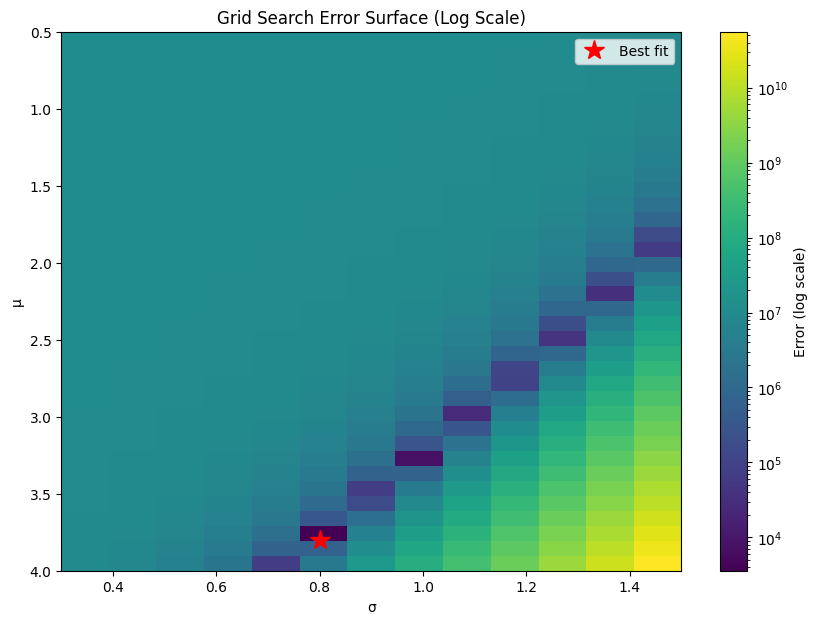

✓ Problem 5: Grid search and heatmap created above


In [10]:
# Visualize the error surface as a heatmap
fig, ax = plt.subplots(figsize=(10, 7))

# Use logarithmic scaling for better visibility of error surface
errors_scaled = results_single['errors'].copy()
errors_scaled[errors_scaled == 0] = 1e-10  # Avoid log(0)

norm = LogNorm(vmin=errors_scaled.min(), vmax=errors_scaled.max())

# Create heatmap with log scaling
im = ax.imshow(
    errors_scaled,
    extent=[results_single['sigma_values'][0], results_single['sigma_values'][-1],
            results_single['mu_values'][-1], results_single['mu_values'][0]],
    aspect='auto',
    cmap='viridis',
    norm=norm
)

# Mark the best point
ax.plot(results_single['best_sigma'], results_single['best_mu'], 'r*', markersize=15, label='Best fit')

ax.set_xlabel('σ')
ax.set_ylabel('μ')
ax.set_title('Grid Search Error Surface (Log Scale)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Error (log scale)')
ax.legend()
plt.show()

print("✓ Problem 5: Grid search and heatmap created above")

## Problem 4: Mixture Estimation via Grid Search (20 pts)

Using the previous example as a guide, implement a grid search to estimate parameters for a **mixture of two log-normal distributions**. You will need to:
1. Grid search over (μ₁, σ₁, μ₂, σ₂, weight) simultaneously
2. For each candidate mixture, compute what the empirical mean and variance *should be*
3. Compare to the actual empirical moments
4. Return the parameters that minimize error

Recall that for a mixture, the mean is:
$$E[X] = \text{weight} \cdot E[X_1] + (1 - \text{weight}) \cdot E[X_2]$$

The variance is:
$$\text{Var}(X) = \text{weight} \cdot \text{Var}(X_1) + (1 - \text{weight}) \cdot \text{Var}(X_2) + \text{weight} \cdot (1 - \text{weight}) \cdot (E[X_1] - E[X_2])^2$$

In [ ]:
def mixture_expected_mean(
    mu1: float, sigma1: float, mu2: float, sigma2: float, weight1: float
) -> float:
    """
    Compute expected mean for a mixture of two log-normals.
    
    Args:
        mu1, sigma1: Parameters of first log-normal
        mu2, sigma2: Parameters of second log-normal
        weight1: Proportion of component 1 (in [0, 1])
    
    Returns:
        Expected mixture mean
    
    TODO: Use theoretical_moments_lognormal() to get each component's mean,
    then blend them with weight1
    """
    # Get moments for each component
    moments1 = theoretical_moments_lognormal(mu1, sigma1)
    moments2 = theoretical_moments_lognormal(mu2, sigma2)
    
    # Weighted sum of means
    mix_mean = weight1 * moments1['mean'] + (1 - weight1) * moments2['mean']
    
    return mix_mean


def mixture_expected_variance(
    mu1: float, sigma1: float, mu2: float, sigma2: float, weight1: float
) -> float:
    """
    Compute expected variance for a mixture of two log-normals.
    
    Using the law of total variance:
    Var(X) = E[Var(X|Z)] + Var(E[X|Z])
    
    Where Z is the mixture component indicator.
    
    Args:
        mu1, sigma1: Parameters of first log-normal
        mu2, sigma2: Parameters of second log-normal
        weight1: Proportion of component 1 (in [0, 1])
    
    Returns:
        Expected mixture variance
    
    TODO: Implement using law of total variance
    E[Var(X|Z)] = weight1 * var1 + (1-weight1) * var2
    Var(E[X|Z]) = weight1 * (mean1 - mixture_mean)² + (1-weight1) * (mean2 - mixture_mean)²
    """
    # Get moments
    moments1 = theoretical_moments_lognormal(mu1, sigma1)
    moments2 = theoretical_moments_lognormal(mu2, sigma2)
    
    # Get mixture mean (needed for the second term)
    mix_mean = mixture_expected_mean(mu1, sigma1, mu2, sigma2, weight1)
    
    # Term 1: E[Var(X|Z)] - Average of variances
    expected_conditional_var = weight1 * moments1['variance'] + (1 - weight1) * moments2['variance']
    
    # Term 2: Var(E[X|Z]) - Variance of means
    # For a binary variable (Bernoulli), variance is p(1-p)(val1-val2)^2, but here explicit sum works too
    var_of_conditional_expectation = (weight1 * (moments1['mean'] - mix_mean)**2) + \
                                     ((1 - weight1) * (moments2['mean'] - mix_mean)**2)
    
    return expected_conditional_var + var_of_conditional_expectation


# Test the mixture functions
mix_mean = mixture_expected_mean(1.0, 0.6, 3.5, 0.8, 0.6)
mix_var = mixture_expected_variance(1.0, 0.6, 3.5, 0.8, 0.6)
print(f"Test mixture with true parameters:")
print(f"  Theoretical mean: {mix_mean:.4f} (empirical: {empirical['mean']:.4f})")
print(f"  Theoretical var:  {mix_var:.4f} (empirical: {empirical['variance']:.4f})")

Test mixture with true parameters:
  Theoretical mean: 20.1943 (empirical: 29.1675)
  Theoretical var:  1178.9759 (empirical: 3346.8896)


In [ ]:
def grid_search_mixture(
    empirical_moments: Dict[str, float],
    mu_range: Tuple[float, float] = (0.5, 4.0),
    sigma_range: Tuple[float, float] = (0.3, 1.5),
    weight_values: np.ndarray = None,
    step: float = 0.3
) -> Dict:
    """
    Grid search to find best (μ₁, σ₁, μ₂, σ₂, weight) for mixture.
    
    Args:
        empirical_moments: Dictionary with 'mean' and 'variance'
        mu_range: Range for μ parameters
        sigma_range: Range for σ parameters
        weight_values: Array of weight values to test (default: 0.3 to 0.7 in steps of 0.1)
        step: Grid step for μ and σ
    
    Returns:
        Dictionary with best parameters and error
    
    TODO: Implement nested loops over all 5 parameters:
    for mu1 in range:
        for sigma1 in range:
            for mu2 in range:
                for sigma2 in range:
                    for weight in weight_values:
                        compute error
    
    Note: This is computationally intensive! Use coarse grids.
    
    Returns the best-fit parameters and their error.
    """
    if weight_values is None:
        weight_values = np.arange(0.3, 0.8, 0.1)
    
    best_error = np.inf
    best_params = {}
    
    # Generate grid points
    mu_vals = np.arange(mu_range[0], mu_range[1] + step, step)
    sigma_vals = np.arange(sigma_range[0], sigma_range[1] + step, step)
    
    print(f"Searching grid: mu={len(mu_vals)}, sigma={len(sigma_vals)}, weights={len(weight_values)}")
    
    for mu1 in mu_vals:
        for sigma1 in sigma_vals:
            for mu2 in mu_vals:
                for sigma2 in sigma_vals:
                    for w in weight_values:
                        # Calculating theoretical mixture statistics
                        mix_mean = mixture_expected_mean(mu1, sigma1, mu2, sigma2, w)
                        mix_var = mixture_expected_variance(mu1, sigma1, mu2, sigma2, w)
                        
                        # Error metric
                        error = (mix_mean - empirical_moments['mean'])**2 + \
                                (mix_var - empirical_moments['variance'])**2
                        
                        if error < best_error:
                            best_error = error
                            best_params = {
                                'mu1': mu1,
                                'sigma1': sigma1,
                                'mu2': mu2,
                                'sigma2': sigma2,
                                'weight1': w,
                                'error': error
                            }
    
    return best_params


# Run mixture grid search (this might take a minute)
print("Running mixture grid search (this may take a moment)...")
results_mixture = grid_search_mixture(empirical)

print(f"\nGrid Search Results (Mixture):")
print(f"  μ₁:          {results_mixture.get('mu1', '?'):.4f}")
print(f"  σ₁:          {results_mixture.get('sigma1', '?'):.4f}")
print(f"  μ₂:          {results_mixture.get('mu2', '?'):.4f}")
print(f"  σ₂:          {results_mixture.get('sigma2', '?'):.4f}")
print(f"  Weight₁:     {results_mixture.get('weight1', '?'):.4f}")
print(f"  Error:       {results_mixture.get('error', '?'):.6f}")

Running mixture grid search (this may take a moment)...
Searching grid: mu=13, sigma=5, weights=5

Grid Search Results (Mixture):
  μ₁:          2.9000
  σ₁:          1.2000
  μ₂:          1.7000
  σ₂:          0.9000
  Weight₁:     0.7000
  Error:       0.577640


You made it!